Our Project
This should be our main commit file for the profs to go through

In [1]:
import Evaluation
import cleaning
import pickle
import pandas as pd
import cleaning

Data cleaning

In [2]:
file_path = "publicdataexportv131450706334_with_lon_lat.xlsx"

In [3]:
# Loading sheets
bus = pd.read_excel(file_path, sheet_name="Bus", header=3)
line = pd.read_excel(file_path, sheet_name="Line", header=3)
gen = pd.read_excel(file_path, sheet_name="Generator", header=3)
load = pd.read_excel(file_path, sheet_name="Load", header=3)
hvdc = pd.read_excel(file_path, sheet_name="HVDC", header=3)
transformer2 = pd.read_excel(file_path, sheet_name="Transformer2", header=3)
transformer3 = pd.read_excel(file_path, sheet_name="Transformer3", header=3)

for df in [bus, line, gen, load, hvdc, transformer2, transformer3]:
    df.columns = [str(c).strip() for c in df.columns]


# This is our main cleaning function that turns our raw data into an unaggregated graph, that is used for the scenario generation
g_unaggregated = cleaning.main_clean(bus, line, gen, load, hvdc, transformer2, transformer3)

e:\Master\Semester3\Advanced Business Analytics\Critical-Energy-Infrastructure-Under-Hybrid-War-Scenarios\cleaning.py:287: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  edges_final = pd.concat([


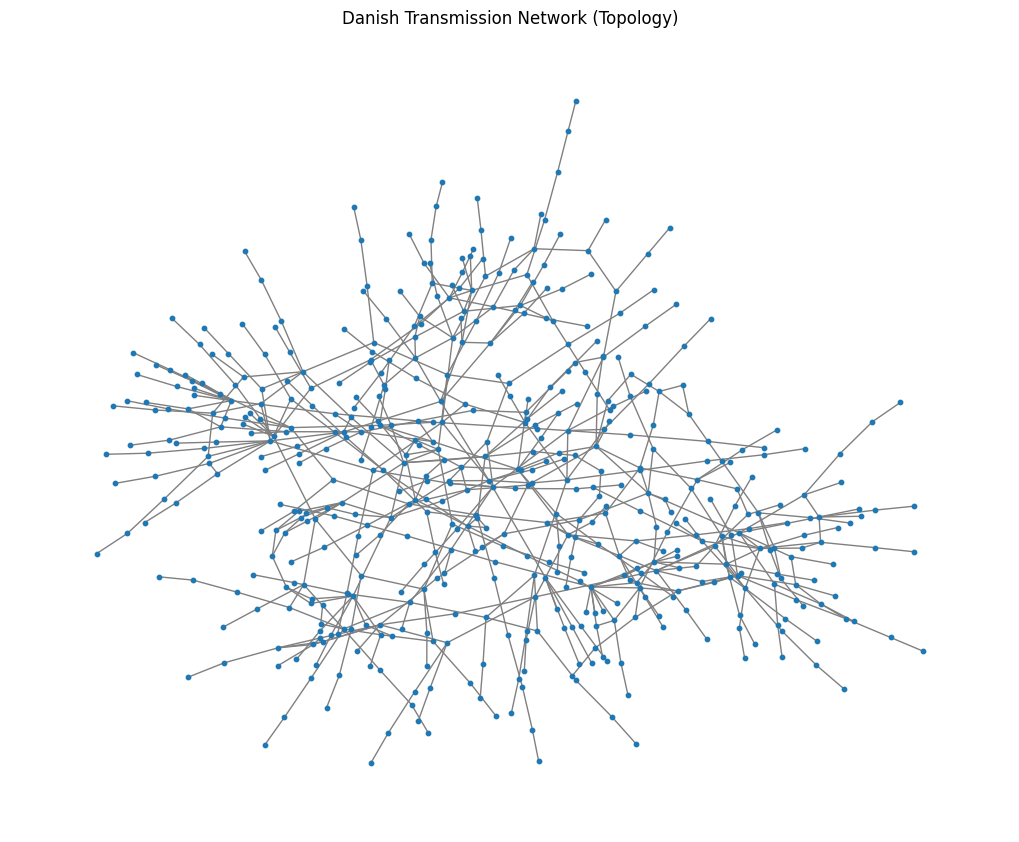

In [4]:
cleaning.print_graph(g_unaggregated)

## Scenario-conditioned attack simulations

Only balanced scenarios (supply ≈ demand after rebalancing) are valid baselines for attack evaluation.
If the grid already has unmet demand before an attack, the simulation results cannot isolate the attack's impact.

In [5]:
base_scenario = g_unaggregated

In [6]:
from scenarios import SCENARIOS, apply_scenario_mean

# ── Check balance for every scenario ─────────────────────────────────────────
BALANCE_TOL_PCT = 1.0   # allow up to 1 % residual gap

balance_rows = []
for sid, scenario in SCENARIOS.items():
    G_sc = apply_scenario_mean(base_scenario, scenario)
    total_supply = sum(d.get('supply', 0.0) for _, d in G_sc.nodes(data=True))
    total_demand = sum(d.get('demand', 0.0) for _, d in G_sc.nodes(data=True))
    gap          = abs(total_supply - total_demand)
    gap_pct      = gap / max(total_demand, 1.0) * 100
    balance_rows.append({
        'scenario_id'     : sid,
        'label'           : scenario['label'],
        'total_supply_MW' : round(total_supply, 1),
        'total_demand_MW' : round(total_demand, 1),
        'gap_MW'          : round(gap, 1),
        'gap_pct'         : round(gap_pct, 3),
        'balanced'        : gap_pct <= BALANCE_TOL_PCT,
    })

balance_df = pd.DataFrame(balance_rows)
balance_df

e:\Master\Semester3\Advanced Business Analytics\Critical-Energy-Infrastructure-Under-Hybrid-War-Scenarios\scenarios.py:478: UserWarning: _rebalance: residual gap = -910.9 MW (-28.8% of demand). Scenario may be structurally infeasible with this grid.
  warnings.warn(
e:\Master\Semester3\Advanced Business Analytics\Critical-Energy-Infrastructure-Under-Hybrid-War-Scenarios\scenarios.py:478: UserWarning: _rebalance: residual gap = -530.4 MW (-16.0% of demand). Scenario may be structurally infeasible with this grid.
  warnings.warn(
e:\Master\Semester3\Advanced Business Analytics\Critical-Energy-Infrastructure-Under-Hybrid-War-Scenarios\scenarios.py:478: UserWarning: _rebalance: residual gap = -1842.2 MW (-90.4% of demand). Scenario may be structurally infeasible with this grid.
  warnings.warn(
e:\Master\Semester3\Advanced Business Analytics\Critical-Energy-Infrastructure-Under-Hybrid-War-Scenarios\scenarios.py:478: UserWarning: _rebalance: residual gap = -890.4 MW (-24.3% of demand). Scen

  pre_remove_top_n: removed 221-0 (400 KV STATION FRAUGDE, betweenness=0.5351)


,scenario_id,label,total_supply_MW,total_demand_MW,gap_MW,gap_pct,balanced
0,S01_high_wind_surplus,High wind — surplus export,4070.1,3159.3,910.9,28.832,False
1,S02_low_wind_import,Low wind — import dependent,4484.1,4484.1,0.0,0.000,True
2,S03_high_solar_midday,High solar — midday duck curve,3842.5,3312.1,530.4,16.013,False
3,S04_low_renewables_dark,Dark winter night — low renewables,3781.1,3770.7,10.4,0.275,True
4,S05_winter_peak_demand,Winter peak demand,5095.6,5095.6,0.0,0.000,True
5,S06_summer_trough,Summer demand trough,3880.4,2038.2,1842.2,90.382,False
6,S07_nordic_drought,Nordic drought — Norway hydro unavailable,4484.1,4484.1,0.0,0.000,True
7,S08_german_grid_stress,German grid stress — limited export south,4840.8,4840.8,0.0,0.000,True
8,S09_cobra_offline,COBRA cable offline (planned maintenance),4559.2,3668.8,890.4,24.270,False
9,S10_storm_day,"Storm day — high wind, derated lines",4076.5,4076.5,0.0,0.000,True


In [7]:
balanced_ids = balance_df.loc[balance_df['balanced'], 'scenario_id'].tolist()
skipped_ids  = balance_df.loc[~balance_df['balanced'], 'scenario_id'].tolist()

print(f"Balanced ({len(balanced_ids)}): {balanced_ids}")
if skipped_ids:
    print(f"Skipped  ({len(skipped_ids)}): {skipped_ids}")

# ── Run single-removal attack simulation for each balanced scenario ──────────
scenario_results_list = []
for sid in balanced_ids:
    scenario = SCENARIOS[sid]
    G_sc = apply_scenario_mean(base_scenario, scenario)
    G_sc.name = sid
    print(f"\n→ {sid}: {scenario['label']}")
    df = Evaluation.simulation_all_single_removals(G_sc)
    df.insert(0, 'scenario_id',    sid)
    df.insert(1, 'scenario_label', scenario['label'])
    scenario_results_list.append(df)

scenario_results = pd.concat(scenario_results_list, ignore_index=True)
scenario_results.to_excel("scenario_results.xlsx", index=False)
print(f"\nSaved {len(scenario_results)} rows to scenario_results.xlsx")

Balanced (9): ['S02_low_wind_import', 'S04_low_renewables_dark', 'S05_winter_peak_demand', 'S07_nordic_drought', 'S08_german_grid_stress', 'S10_storm_day', 'S11_storebelt_degraded', 'S12_gas_shortage', 'S13_second_strike']
Skipped  (4): ['S01_high_wind_surplus', 'S03_high_solar_midday', 'S06_summer_trough', 'S09_cobra_offline']

→ S02_low_wind_import: Low wind — import dependent

→ S04_low_renewables_dark: Dark winter night — low renewables

→ S05_winter_peak_demand: Winter peak demand


KeyboardInterrupt: 

In [ ]:
scenario_results.sort_values('total_unmet_demand_MW', ascending=False).head(20)